# Grid search, nested CV, and evaluation metrics

Key structure:
- grid search with cross-validation
- analyzing CV results
- using different CV strategies
- nested CV
- parallelization
- evaluation metrics for classification and regression
- choosing a scoring metric for model selection

## 1. Core idea

A single train/validation split is unstable.
A better workflow is:
1. define a model and a parameter grid
2. use cross-validation on the training data
3. pick the paramater setting with the best mean CV score
4. evaluate once on a final test set

This is the main point of grid search with CV: parameter tuning should be done inside CV, not by repeatedly peeking at the test set.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_regression
from sklearn.model_selection import(
    train_test_split, GridSearchCV, StratifiedKFold, KFold,
    ShuffleSplit, StratifiedShuffleSplit, cross_val_score
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, f1_score,
    accuracy_score, r2_score, mean_squared_error, mean_absolute_error
)
np.random.seed(0)

## 2. Grid search with cross-validation

A standard example is an SVM with `C` and `gamma`.

The saerch is done over a grid of parameter combinations, and each combination is evaluated by cross-validation.


In [4]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

pipe = make_pipeline(StandardScaler(), SVC())

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe, 
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True, 
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best mean CV accuracy:", round(grid.best_score_, 3))
print("Test accuracy:", round(grid.score(X_test, y_test), 3))


Best params: {'svc__C': 10, 'svc__gamma': 0.1}
Best mean CV accuracy: 0.965
Test accuracy: 1.0


The dataset is first split into a training set and a final test set.
Grid search with cv is then performed only on the training set.
Within this process, each parameter combination is evaluated by averaging validation scores across the CV folds.
The final test set is used only once, after model selection, to estimate generalization performance.

## 3. Analyzing grid-search results
- are many settings similarly good?
- is the best point on the boundary of the grid?
- is one parameter doing all the work?
- did you search a useless range?


In [9]:
results = pd.DataFrame(grid.cv_results_)
cols = ["param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score", "rank_test_score"]
results[cols].sort_values("rank_test_score").head(8)

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
9,10.0,0.10,0.964822,0.032651,1
12,100.0,0.01,0.956126,0.038896,2
6,1.0,1.00,0.938340,0.044039,3
5,1.0,0.10,0.937945,0.065302,4
8,10.0,0.01,0.937945,0.044676,4
10,10.0,1.00,0.929644,0.051786,6
4,1.0,0.01,0.928854,0.021027,7
1,0.1,0.10,0.920553,0.041632,8


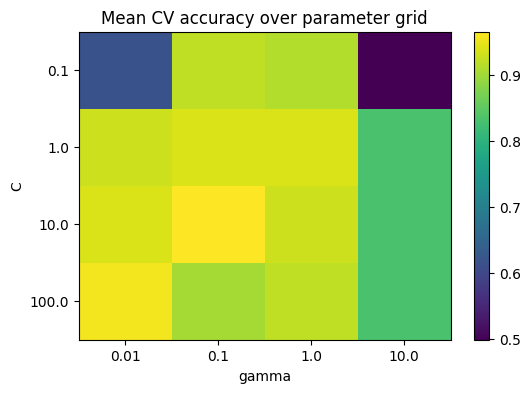

In [15]:
score_table = results.pivot_table(
    values="mean_test_score",
    index="param_svc__C",
    columns="param_svc__gamma"
)

plt.figure(figsize=(6, 4))
im = plt.imshow(score_table, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(score_table.columns)), score_table.columns)
plt.yticks(range(len(score_table.index)), score_table.index)
plt.xlabel("gamma")
plt.ylabel("C")
plt.title("Mean CV accuracy over parameter grid")
plt.show()


## 4. Different CV strategies inside grid search

`GridSearchCV` uses classification/regression defaults, nbut you can pass any splitter via `cv=`

Use alternatives when:
- data is imbalanced -> `stratitifiedKFold`
- data is huge and a full K-fold is expensive -> `ShuffleSplit` or `StratifiedShuffleSplit`
- regression -> KFold

In [17]:
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.25, random_state=0)

grid_sss = GridSearchCV(
    pipe, 
    param_grid=param_grid,
    cv=sss,
    scoring="accuracy",
    n_jobs=1
)

grid_sss.fit(X_train, y_train)

print("Best params with StratifiedShuffleSplit:", grid_sss.best_params_)
print("Best mean CV accuracy:", round(grid_sss.best_score_, 3))

Best params with StratifiedShuffleSplit: {'svc__C': 1, 'svc__gamma': 0.1}
Best mean CV accuracy: 0.943


## 5. Nested cross-validation

When `GridSearchCV` is used on one training/test split, the final test score still depends on that one split.

Nested CV adds an outer CV loop:

- inner loop: choose hyperparameters
- outer loop: estimate generalization performance

The result is a distribution of outer test scores, not one final fitted model.

Use it when the goal is to estimate how well a whole model-selection procedure generalizes.

In [18]:
nested_scores = cross_val_score(
    GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="accuracy"),
    X, y,
    cv=cv
)
print("Nested CV scores:", np.round(nested_scores, 3))
print("Mean nested CV score:", round(nested_scores.mean(), 3))

Nested CV scores: [1.    0.967 0.9   0.967 0.933]
Mean nested CV score: 0.953


Interpretation:

Nested CV answers a question like:
>If I repeat the full hyperparameter-tuning workflow on new samples from the same population, how well will it do on average?

It is usually more expensive than ordinary CV because the full grid search runs inside each outer fold.

## 6. Parallelization

Both cross-validation and grid search are embarrassingly parallel:
each fold × parameter combination can be evaluated independently.

In `scikit-learn`, use:
- `n_jobs=-1` to use all available CPU cores
- `n_jobs=1` for deterministic, simple runs

Be careful with memory usage when both the dataset and model are large.

## 7. Evaluation metrics: keep the end goal in mind

Accuracy is not always the right metric.
A model can have high accuracy but still be bad for the real decision problem, especially when:
- classes are imbalanced
- false positives and false negatives have different costs

## 8. Binary classification metrics

We will use the breast cancer dataset and convert the positive class to `"malignant"` (1)

In [29]:
cancer = load_breast_cancer()
Xc, yc = cancer.data, (cancer.target == 0).astype(int)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, stratify=yc, random_state=0)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

clf.fit(Xc_train, yc_train)

yc_pred = clf.predict(Xc_test)

print("Accuracy :", round(accuracy_score(yc_test, yc_pred), 3))
print("Precision:", round(precision_score(yc_test, yc_pred), 3))
print("Recall   :", round(recall_score(yc_test, yc_pred), 3))
print("F1       :", round(f1_score(yc_test, yc_pred), 3))
print("\nConfusion matrix:")
print(confusion_matrix(yc_test, yc_pred))
print(classification_report(yc_test, yc_pred, target_names=["benign", "malignant"]))

Accuracy : 0.986
Precision: 1.0
Recall   : 0.962
F1       : 0.981

Confusion matrix:
[[90  0]
 [ 2 51]]
              precision    recall  f1-score   support

      benign       0.98      1.00      0.99        90
   malignant       1.00      0.96      0.98        53

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143



### Key metrics

- **Precision**: among predicted positives, how many are truly positive?
- **Recall**: among actual positives, how many did we find?
- **F1**: harmonic mean of precision and recall
- **Confusion matrix**: raw counts of TP, FP, FN, TN

## 9. Dcision scores, thresholds, precsion-recacall, ROC

Many classifiers produce a continuous score before the final class label.
Changing the threshold changes precision and recall.

The evaluation should match the use case: sometimes we want high recall, sometimes high precision, sometimes strong ranking performance.

Average precision: 0.994
ROC AUC: 0.996


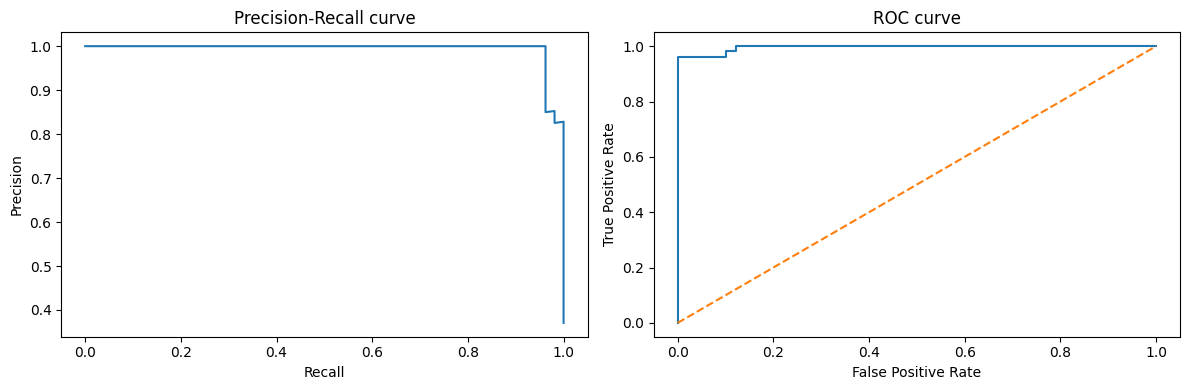

In [37]:
decision_scores = clf.decision_function(Xc_test)

precisions, recalls, pr_thresholds = precision_recall_curve(yc_test, decision_scores)
fpr, tpr, roc_thresholds = roc_curve(yc_test, decision_scores)

ap = average_precision_score(yc_test, decision_scores)
auc = roc_auc_score(yc_test, decision_scores)

print("Average precision:", round(ap, 3))
print("ROC AUC:", round(auc, 3))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")

plt.tight_layout()
plt.show()